In [ ]:
%load_ext autoreload
%autoreload 2

# Case study: Kwon–Cheong bogus vortex for Typhoon Mawar (WP02 2023)

Uses the real HRES analysis on-disk at `data/hres_atmos_20230526_fh00_06_12_18.grb`
and `data/hres_surf_20230526.grb`, together with the JTWC ATCF b-deck at
`data/bwp022023.dat`, to exercise the tcinit pipeline end-to-end.

Target time: **2023-05-26 12Z**, when Mawar was at peak intensity
(≈165 kt / 891 hPa in the b-deck; the HRES analysis carries a much weaker
representation of the storm that we intensify to match).

The notebook:

1. Loads the best-track record for the target time.
2. Slices a 30°×30° box out of the 13 GB HRES grib and caches it as netCDF.
3. Plots the baseline HRES snapshot.
4. Detects the storm and builds the K&C bogus vortex.
5. Applies the vortex and plots the post-bogus snapshot.
6. Plots the vortex's own radial / vertical structure.
7. Exercises each of the four model-specific backends (HICCUP, WN-2, SFNO, Aurora)
   on the same data so the round-trip contract is validated end-to-end.


## Setup

In [ ]:
import os
import warnings
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

warnings.filterwarnings("ignore")

from tcinit.best_track import BestTrack
from tcinit.snapshot import Snapshot
from tcinit.ideal_tc_vortex import BogusVortex
from tcinit.backends import (
    xarray_backend,
    hiccup_backend,
    weathernext2_backend as wn2_backend,
    sfno_backend,
)
from tcinit.constants import HPA_TO_PA

BEST_TRACK = "/workspace/data/bwp022023.dat"
ATMOS_GRB  = "/workspace/data/hres_atmos_20230526_fh00_06_12_18.grb"
SFC_GRB    = "/workspace/data/hres_surf_20230526.grb"

TARGET_TIME  = datetime(2023, 5, 26, 12)
BOX_HALF_DEG = 15.0
CACHE_DIR    = "/workspace/data/case_study_wp02_2023"
os.makedirs(CACHE_DIR, exist_ok=True)


## 1. Best-track record for target time

In [ ]:
bt = BestTrack(BEST_TRACK)
lat_c, lon_c = bt.get_location(TARGET_TIME)
vmax_ms = bt.get_windspeed(TARGET_TIME)
pmin_pa = bt.get_central_pressure(TARGET_TIME)
print(f"Mawar at {TARGET_TIME}:")
print(f"  location = ({lat_c:.2f} N, {lon_c:.2f} E)")
print(f"  vmax     = {vmax_ms:.1f} m/s")
print(f"  MSLP     = {pmin_pa/HPA_TO_PA:.1f} hPa")


## 2. Load HRES data (with box cache)

The atmos grib is 13 GB; we slice a 30°×30° box around the best-track location
and cache it as netCDF so re-runs are instant.


In [ ]:
atmos_cache = f"{CACHE_DIR}/atmos_box_{TARGET_TIME:%Y%m%d_%HZ}.nc"
sfc_cache   = f"{CACHE_DIR}/sfc_box_{TARGET_TIME:%Y%m%d_%HZ}.nc"


def _slice_grb(path, target_time, lat_c, lon_c, half):
    ds = xr.open_dataset(path, engine="cfgrib", backend_kwargs={"indexpath": ""})
    ti = int(np.where(ds.time.values == np.datetime64(target_time))[0][0])
    lat_mask = (ds.latitude >= lat_c - half) & (ds.latitude <= lat_c + half)
    lon_mask = (ds.longitude >= lon_c - half) & (ds.longitude <= lon_c + half)
    box = ds.isel(time=ti).where(lat_mask & lon_mask, drop=True).load()
    ds.close()
    return box


if os.path.exists(atmos_cache):
    atmos_box = xr.open_dataset(atmos_cache)
else:
    print("Cache miss — slicing atmos grib (~15 s)...")
    atmos_box = _slice_grb(ATMOS_GRB, TARGET_TIME, lat_c, lon_c, BOX_HALF_DEG)
    atmos_box.to_netcdf(atmos_cache)

if os.path.exists(sfc_cache):
    sfc_box = xr.open_dataset(sfc_cache)
else:
    print("Cache miss — slicing sfc grib (~5 s)...")
    sfc_box = _slice_grb(SFC_GRB, TARGET_TIME, lat_c, lon_c, BOX_HALF_DEG)
    sfc_box.to_netcdf(sfc_cache)

print("Atmos box:", dict(atmos_box.sizes))
print("Sfc box:  ", dict(sfc_box.sizes))
print("Atmos vars:", list(atmos_box.data_vars))
print("Sfc vars:  ", list(sfc_box.data_vars))


## 3. Assemble the canonical Dataset

`tcinit.snapshot.Snapshot` / `tcinit.ideal_tc_vortex.BogusVortex` operate on an xarray
Dataset with canonical short variable names (`t, u, v, q, z, msl, 2t, 10u, 10v`)
and dims `(level, latitude, longitude)`.

In [ ]:
canon = xr.Dataset(
    data_vars={
        "t":   (("level", "latitude", "longitude"), atmos_box["t"].values),
        "u":   (("level", "latitude", "longitude"), atmos_box["u"].values),
        "v":   (("level", "latitude", "longitude"), atmos_box["v"].values),
        "q":   (("level", "latitude", "longitude"), atmos_box["q"].values),
        "z":   (("level", "latitude", "longitude"), atmos_box["z"].values),
        "msl": (("latitude", "longitude"),          sfc_box["msl"].values),
        "2t":  (("latitude", "longitude"),          sfc_box["t2m"].values),
        "10u": (("latitude", "longitude"),          sfc_box["u10"].values),
        "10v": (("latitude", "longitude"),          sfc_box["v10"].values),
    },
    coords={
        "latitude":  atmos_box.latitude.values,
        "longitude": atmos_box.longitude.values,
        "level":     atmos_box.isobaricInhPa.values,
    },
)
print("Canonical box:", dict(canon.sizes))


## 4. Baseline snapshot plots

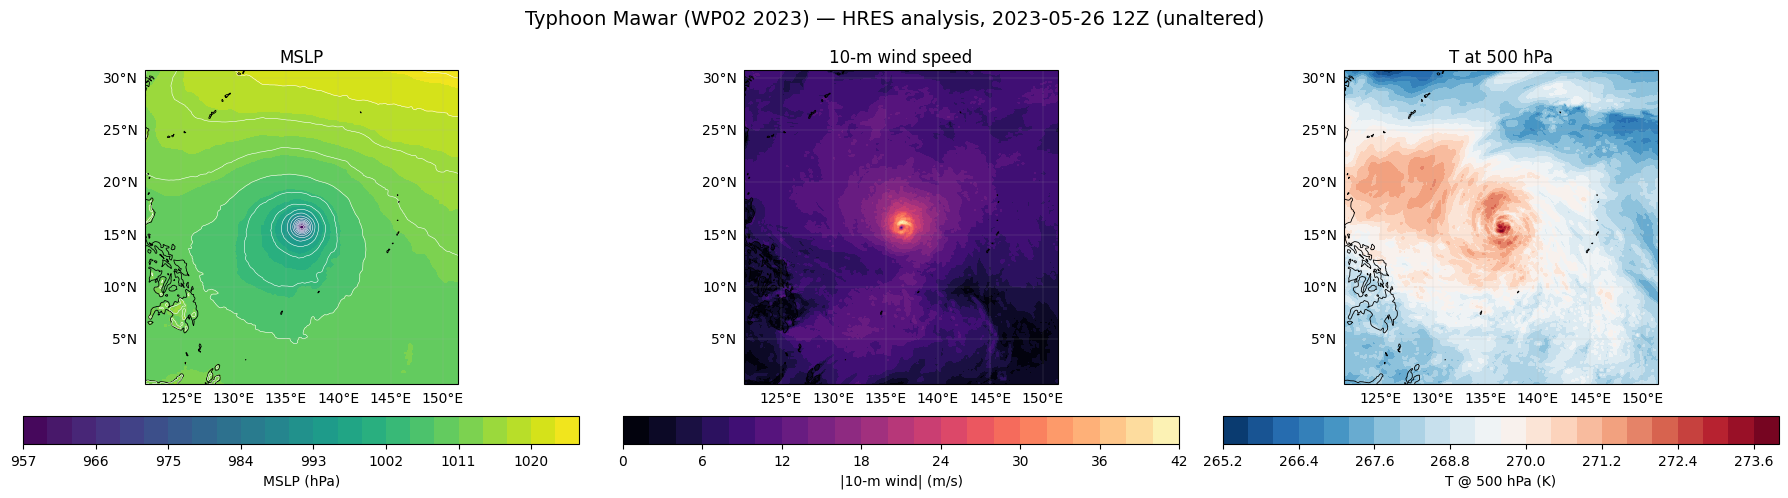

In [ ]:
def _mapfig(nrow, ncol, figsize=(18, 5)):
    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        nrow, ncol, figsize=figsize, subplot_kw={"projection": proj}
    )
    axes = np.atleast_1d(axes).ravel()
    return fig, axes, proj


def _mapdraw(ax, extent):
    ax.coastlines(resolution="50m", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
    gl.top_labels = False
    gl.right_labels = False


def plot_snapshot(ds, title):
    lats, lons = ds["latitude"].values, ds["longitude"].values
    extent = [lons.min(), lons.max(), lats.min(), lats.max()]
    fig, axes, proj = _mapfig(1, 3, figsize=(18, 5))

    msl = ds["msl"].values / HPA_TO_PA
    im = axes[0].contourf(lons, lats, msl, levels=25, cmap="viridis", transform=proj)
    axes[0].contour(lons, lats, msl, levels=np.arange(900, 1030, 4),
                    colors="w", linewidths=0.4, transform=proj)
    _mapdraw(axes[0], extent)
    plt.colorbar(im, ax=axes[0], orientation="horizontal", pad=0.08, label="MSLP (hPa)")
    axes[0].set_title("MSLP")

    wspd10 = np.hypot(ds["10u"].values, ds["10v"].values)
    im = axes[1].contourf(lons, lats, wspd10, levels=25, cmap="magma", transform=proj)
    _mapdraw(axes[1], extent)
    plt.colorbar(im, ax=axes[1], orientation="horizontal", pad=0.08, label="|10-m wind| (m/s)")
    axes[1].set_title("10-m wind speed")

    T500 = ds["t"].sel(level=500).values
    im = axes[2].contourf(lons, lats, T500, levels=25, cmap="RdBu_r", transform=proj)
    _mapdraw(axes[2], extent)
    plt.colorbar(im, ax=axes[2], orientation="horizontal", pad=0.08, label="T @ 500 hPa (K)")
    axes[2].set_title("T at 500 hPa")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    return fig


fig = plot_snapshot(
    canon,
    f"Typhoon Mawar (WP02 2023) — HRES analysis, {TARGET_TIME:%Y-%m-%d %HZ} (unaltered)",
)
plt.show()


## 5. Snapshot + storm detection

`Snapshot.detect_storm` locates the MSLP minimum inside a search disk (450 km
default) around the box centre, then estimates the radius of maximum wind and
the radius of maximum |∇MSLP| — the smaller of the two becomes `snap.rdr`,
which K&C uses as the radius of maximum tangential wind.


In [ ]:
snap = Snapshot.from_xarray(canon, storm_radius_multiplier=3.0)
snap.detect_storm(box_center=(lat_c, lon_c), max_loc_error_km=450.0, verbose=True)


## 6. Build the Kwon–Cheong bogus vortex

`BogusVortex(snapshot, best_track, target_time).build()` reads `p_c`, `V_m`,
`R_v` from the snapshot + best-track record and constructs the K&C 2009
analytic vortex — tangential wind, radial wind, warm-core T anomaly,
geopotential perturbation, and humidity envelope — on a common `(level,
lat, lon)` grid.


In [ ]:
bv = BogusVortex(snap, bt, TARGET_TIME).build()
print(f"p_c = {bv.p_c/HPA_TO_PA:.1f} hPa   (best-track central pressure)")
print(f"p_a = {bv.p_a/HPA_TO_PA:.1f} hPa   (K&C Table-2 ambient-pressure bin)")
print(f"V_m = {bv.V_m:.1f} m/s      (max tangential wind)")
print(f"R_v = {bv.R_v_km:.1f} km    (radius of max wind, from snap.rdr)")
print(f"r_30 = {bv.r_30_km:.1f} km  (34-kt radius, default 250 km when RAD34 missing)")


## 7. Apply the vortex and plot the post-bogus snapshot

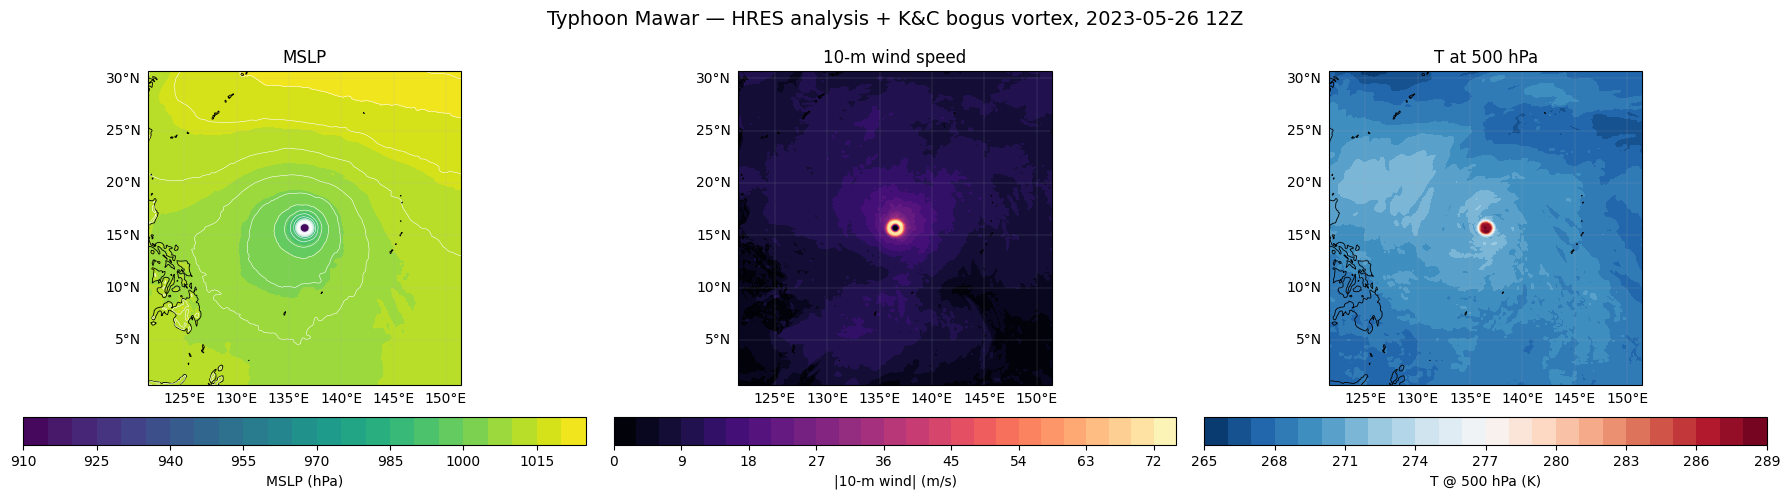

In [ ]:
canon_bogus = xarray_backend.apply(canon, bv)
delta_msl = (canon["msl"] - canon_bogus["msl"]).values / HPA_TO_PA
print(f"Max MSLP drop from bogus:  {np.max(delta_msl):.1f} hPa")
print(f"Min MSLP after bogus:      "
      f"{np.min(canon_bogus['msl'].values)/HPA_TO_PA:.1f} hPa "
      f"(best-track {pmin_pa/HPA_TO_PA:.1f} hPa)")

fig = plot_snapshot(
    canon_bogus,
    f"Typhoon Mawar — HRES analysis + K&C bogus vortex, {TARGET_TIME:%Y-%m-%d %HZ}",
)
plt.show()


## 8. Vortex diagnostic plots

The `BogusVortex` object exposes the radial-mean profiles it built the 3-D
fields from. These are the cleanest view of the K&C structure.


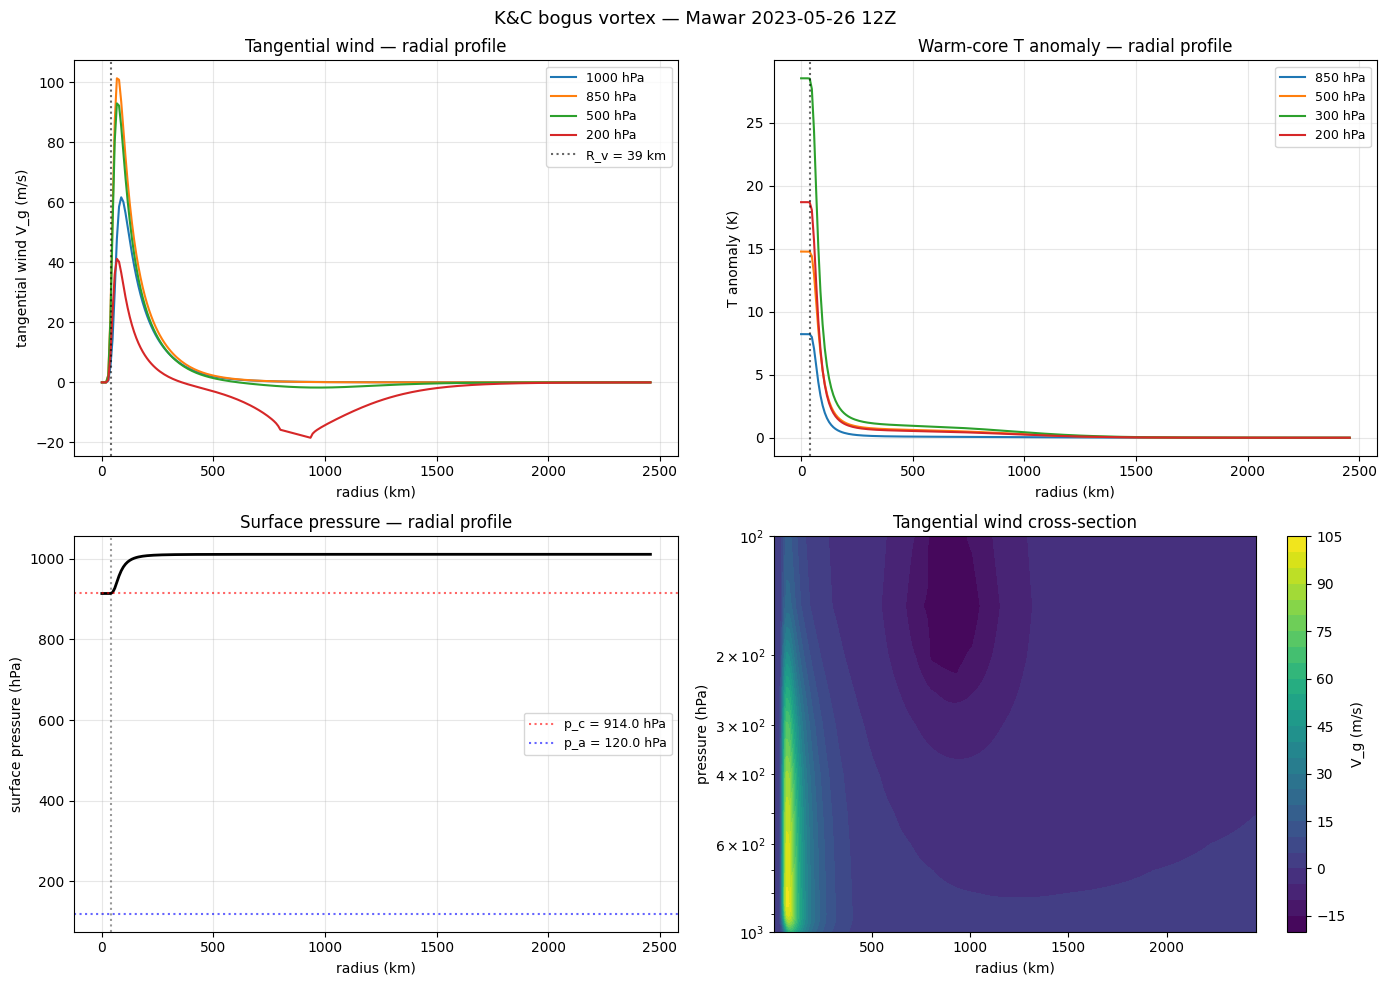

In [ ]:
def plot_vortex_diagnostics(bv):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    for k, p_hpa in enumerate(bv.levels_hpa):
        if p_hpa in (1000, 850, 500, 200):
            ax.plot(bv.r_radial_km, bv.V_g_radial_mps[k], label=f"{int(p_hpa)} hPa")
    ax.axvline(bv.R_v_km, ls=":", color="k", alpha=0.6,
               label=f"R_v = {bv.R_v_km:.0f} km")
    ax.set_xlabel("radius (km)"); ax.set_ylabel("tangential wind V_g (m/s)")
    ax.set_title("Tangential wind — radial profile")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax = axes[0, 1]
    for k, p_hpa in enumerate(bv.levels_hpa):
        if p_hpa in (850, 500, 300, 200):
            ax.plot(bv.r_radial_km, bv.T_anom_radial_K[k], label=f"{int(p_hpa)} hPa")
    ax.axvline(bv.R_v_km, ls=":", color="k", alpha=0.6)
    ax.set_xlabel("radius (km)"); ax.set_ylabel("T anomaly (K)")
    ax.set_title("Warm-core T anomaly — radial profile")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax = axes[1, 0]
    ax.plot(bv.r_radial_km, bv.p_sfc_radial_pa / HPA_TO_PA, "k-", lw=2)
    ax.axhline(bv.p_c / HPA_TO_PA, ls=":", color="r", alpha=0.6,
               label=f"p_c = {bv.p_c/HPA_TO_PA:.1f} hPa")
    ax.axhline(bv.p_a / HPA_TO_PA, ls=":", color="b", alpha=0.6,
               label=f"p_a = {bv.p_a/HPA_TO_PA:.1f} hPa")
    ax.axvline(bv.R_v_km, ls=":", color="k", alpha=0.4)
    ax.set_xlabel("radius (km)"); ax.set_ylabel("surface pressure (hPa)")
    ax.set_title("Surface pressure — radial profile")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax = axes[1, 1]
    R, P = np.meshgrid(bv.r_radial_km, bv.levels_hpa)
    im = ax.contourf(R, P, bv.V_g_radial_mps, levels=25, cmap="viridis")
    ax.set_ylim(1000, 100); ax.set_yscale("log")
    ax.set_xlabel("radius (km)"); ax.set_ylabel("pressure (hPa)")
    ax.set_title("Tangential wind cross-section")
    plt.colorbar(im, ax=ax, label="V_g (m/s)")

    fig.suptitle(f"K&C bogus vortex — Mawar {TARGET_TIME:%Y-%m-%d %HZ}", fontsize=13)
    fig.tight_layout()
    return fig


fig = plot_vortex_diagnostics(bv)
plt.show()


## 9. Backend round-trips

Each backend implements the same three-function contract
(`extract_snapshot_dataset` / `apply` / `write_back`) so the same Snapshot +
BogusVortex core can drive vortex injection into each model's native
initial-condition container. Below we exercise all four on the real data.

`SFNO` and `Aurora` cells are gated on their optional dependencies (`torch`,
`microsoft-aurora`) and skip cleanly if those aren't installed.


### 9.1 HICCUP (ERA5 netCDF file lifecycle)

HICCUP's ERA5 subclass consumes CDS-shape netCDF files. We save the HRES box
in that shape, then let `hiccup_backend` do the extract → apply → `.tc_bogus.nc`
sibling write.


In [ ]:
hiccup_atm_nc = f"{CACHE_DIR}/hiccup_atm_source.nc"
hiccup_sfc_nc = f"{CACHE_DIR}/hiccup_sfc_source.nc"
_dt = np.array([np.datetime64(TARGET_TIME)])

atm_ds = xr.Dataset(
    data_vars={n: (("valid_time", "pressure_level", "latitude", "longitude"),
                   canon[n].values[None, ...])
               for n in ("t", "u", "v", "q", "z")},
    coords={"latitude": canon.latitude.values, "longitude": canon.longitude.values,
            "pressure_level": canon.level.values, "valid_time": _dt},
)
sfc_ds = xr.Dataset(
    data_vars={
        "msl": (("valid_time", "latitude", "longitude"), canon["msl"].values[None]),
        "t2m": (("valid_time", "latitude", "longitude"), canon["2t"].values[None]),
        "u10": (("valid_time", "latitude", "longitude"), canon["10u"].values[None]),
        "v10": (("valid_time", "latitude", "longitude"), canon["10v"].values[None]),
    },
    coords={"latitude": canon.latitude.values, "longitude": canon.longitude.values,
            "valid_time": _dt},
)
atm_ds.to_netcdf(hiccup_atm_nc); sfc_ds.to_netcdf(hiccup_sfc_nc)

box_h = hiccup_backend.extract_snapshot_dataset(
    [hiccup_atm_nc, hiccup_sfc_nc],
    box_center=(lat_c, lon_c), box_size=BOX_HALF_DEG - 1.0,
)
snap_h = Snapshot.from_xarray(box_h).detect_storm(
    box_center=(lat_c, lon_c), max_loc_error_km=450.0
)
bv_h = BogusVortex(snap_h, bt, TARGET_TIME).build()
mod_h = hiccup_backend.apply(box_h, bv_h)

atm_out = hiccup_backend.write_back(
    hiccup_atm_nc, mod_h,
    box_lats=box_h.latitude.values, box_lons=box_h.longitude.values, overwrite=True,
)
sfc_out = hiccup_backend.write_back(
    hiccup_sfc_nc, mod_h,
    box_lats=box_h.latitude.values, box_lons=box_h.longitude.values, overwrite=True,
)

# Verify: MSLP min at storm centre in the written sfc file.
_new = xr.open_dataset(sfc_out)
lat_mask = (_new.latitude >= lat_c - 5) & (_new.latitude <= lat_c + 5)
lon_mask = (_new.longitude >= lon_c - 5) & (_new.longitude <= lon_c + 5)
sub_msl = _new["msl"].where(lat_mask & lon_mask, drop=True).values / HPA_TO_PA
print(f"HICCUP wrote {atm_out}")
print(f"HICCUP wrote {sfc_out}")
print(f"HICCUP sfc.tc_bogus.nc: MSLP min inside 5° box = {np.nanmin(sub_msl):.1f} hPa")
_new.close()


### 9.2 WeatherNext-2 (xarray in-memory)

WN-2's native container is xarray with dims `(batch, time, [level,] lat, lon)`
and long-form CF names. We reshape the canonical box into that layout,
duplicate the single HRES analysis into both 6-hourly input slots (matching
WN2's `input_duration="12h"`), and let `wn2_backend` do the round-trip.


In [ ]:
def _rep2d(arr, n_time=2):
    return np.repeat(arr[None], n_time, axis=0)[None]  # (batch=1, time, lat, lon)


def _rep3d(arr, n_time=2):
    return np.repeat(arr[None], n_time, axis=0)[None]  # (batch=1, time, level, lat, lon)


wn_ds = xr.Dataset(
    data_vars={
        "mean_sea_level_pressure":   (("batch", "time", "lat", "lon"),
                                      _rep2d(canon["msl"].values)),
        "2m_temperature":            (("batch", "time", "lat", "lon"),
                                      _rep2d(canon["2t"].values)),
        "10m_u_component_of_wind":   (("batch", "time", "lat", "lon"),
                                      _rep2d(canon["10u"].values)),
        "10m_v_component_of_wind":   (("batch", "time", "lat", "lon"),
                                      _rep2d(canon["10v"].values)),
        "temperature":               (("batch", "time", "level", "lat", "lon"),
                                      _rep3d(canon["t"].values)),
        "u_component_of_wind":       (("batch", "time", "level", "lat", "lon"),
                                      _rep3d(canon["u"].values)),
        "v_component_of_wind":       (("batch", "time", "level", "lat", "lon"),
                                      _rep3d(canon["v"].values)),
        "specific_humidity":         (("batch", "time", "level", "lat", "lon"),
                                      _rep3d(canon["q"].values)),
        "geopotential":              (("batch", "time", "level", "lat", "lon"),
                                      _rep3d(canon["z"].values)),
    },
    coords={
        "lat":   canon.latitude.values,
        "lon":   canon.longitude.values,
        "level": canon.level.values,
        "time":  np.array([np.datetime64(TARGET_TIME) - np.timedelta64(6, "h"),
                           np.datetime64(TARGET_TIME)]),
        "batch": np.array([0]),
    },
)

box_wn = wn2_backend.extract_snapshot_dataset(
    wn_ds, box_center=(lat_c, lon_c), box_size=BOX_HALF_DEG - 1.0
)
snap_wn = Snapshot.from_xarray(
    box_wn,
    var_map={"msl": "mean_sea_level_pressure", "2t": "2m_temperature",
             "10u": "10m_u_component_of_wind", "10v": "10m_v_component_of_wind"},
).detect_storm(box_center=(lat_c, lon_c), max_loc_error_km=450.0)
bv_wn = BogusVortex(snap_wn, bt, TARGET_TIME).build()
mod_wn = wn2_backend.apply(box_wn, bv_wn)
wn_out = wn2_backend.write_back(
    wn_ds, mod_wn,
    box_lats=box_wn.latitude.values, box_lons=box_wn.longitude.values,
)

lat_mask = (wn_out.lat >= lat_c - 5) & (wn_out.lat <= lat_c + 5)
lon_mask = (wn_out.lon >= lon_c - 5) & (wn_out.lon <= lon_c + 5)
sub = wn_out["mean_sea_level_pressure"].isel(batch=0, time=1).where(
    lat_mask & lon_mask, drop=True
).values / HPA_TO_PA
print(f"WN2: MSLP min inside 5° box (slot 1) = {np.nanmin(sub):.1f} hPa")

sub0 = wn_out["mean_sea_level_pressure"].isel(batch=0, time=0).where(
    lat_mask & lon_mask, drop=True).values
sub1 = wn_out["mean_sea_level_pressure"].isel(batch=0, time=1).where(
    lat_mask & lon_mask, drop=True).values
print(f"WN2: both time slots agree inside box? {np.allclose(sub0, sub1)}")
print(f"WN2: 100m wind absent (K&C skips)? "
      f"{'100m_u_component_of_wind' not in wn_out.data_vars}")


### 9.3 SFNO (torch tensor + earth2studio CoordSystem)

SFNO's native container is a `torch.Tensor` shaped
`(batch, time, lead_time, variable, lat, lon)` where the `variable` axis
carries all 73 channels in a flat, per-level naming scheme. We interpolate
HRES's 25 levels down to SFNO's 13, assemble the tensor, and let
`sfno_backend` handle the extract/apply/write-back.

Gated on torch. Skips cleanly on machines that don't have it.


In [ ]:
try:
    import torch  # noqa
    _have_torch = True
except ImportError:
    _have_torch = False

if not _have_torch:
    print("torch not installed — SFNO backend cell skipped.")
else:
    from collections import OrderedDict
    from tcinit.naming import SFNO_LEVELS_HPA, sfno_variables_73

    variables = np.array(sfno_variables_73())
    atmos_sfno = atmos_box.interp(isobaricInhPa=list(SFNO_LEVELS_HPA))
    n_lat, n_lon = atmos_sfno.latitude.size, atmos_sfno.longitude.size
    x = np.zeros((1, 1, 1, variables.size, n_lat, n_lon), dtype=np.float32)

    def _ch(name):
        return int(np.where(variables == name)[0][0])

    x[..., _ch("msl"), :, :] = sfc_box["msl"].values
    x[..., _ch("t2m"), :, :] = sfc_box["t2m"].values
    x[..., _ch("u10m"), :, :] = sfc_box["u10"].values
    x[..., _ch("v10m"), :, :] = sfc_box["v10"].values
    for k, lev in enumerate(SFNO_LEVELS_HPA):
        x[..., _ch(f"t{lev}"), :, :] = atmos_sfno["t"].values[k]
        x[..., _ch(f"u{lev}"), :, :] = atmos_sfno["u"].values[k]
        x[..., _ch(f"v{lev}"), :, :] = atmos_sfno["v"].values[k]
        x[..., _ch(f"q{lev}"), :, :] = atmos_sfno["q"].values[k]
        x[..., _ch(f"z{lev}"), :, :] = atmos_sfno["z"].values[k]

    coords = OrderedDict({
        "batch":     np.arange(1),
        "time":      np.array([np.datetime64(TARGET_TIME)]),
        "lead_time": np.array([np.timedelta64(0, "h")]),
        "variable":  variables,
        "lat":       atmos_sfno.latitude.values,
        "lon":       atmos_sfno.longitude.values,
    })

    box_sfno = sfno_backend.extract_snapshot_dataset(
        x, coords, box_center=(lat_c, lon_c), box_size=BOX_HALF_DEG - 1.0
    )
    snap_sfno = Snapshot.from_xarray(box_sfno).detect_storm(
        box_center=(lat_c, lon_c), max_loc_error_km=450.0
    )
    bv_sfno = BogusVortex(snap_sfno, bt, TARGET_TIME).build()
    mod_sfno = sfno_backend.apply(box_sfno, bv_sfno)
    sfno_backend.write_back(
        x, coords, mod_sfno,
        box_lats=box_sfno.latitude.values, box_lons=box_sfno.longitude.values,
    )
    msl_ch = _ch("msl")
    lat_mask = (coords["lat"] >= lat_c - 5) & (coords["lat"] <= lat_c + 5)
    lon_mask = (coords["lon"] >= lon_c - 5) & (coords["lon"] <= lon_c + 5)
    sub = x[0, 0, 0, msl_ch][np.ix_(lat_mask, lon_mask)] / HPA_TO_PA
    print(f"SFNO: MSLP min inside 5° box = {np.min(sub):.1f} hPa")


### 9.4 Aurora (microsoft-aurora Batch)

Aurora's native container is an `aurora.Batch` with `surf_vars` / `atmos_vars`
dicts of `torch.Tensor` and a `metadata` namespace. We construct one from the
canonical box and let `aurora_backend` do the round-trip.

Gated on `microsoft-aurora` (which brings torch as a dependency).


In [ ]:
try:
    from aurora import Batch, Metadata  # noqa
    _have_aurora = True
except ImportError:
    _have_aurora = False

if not _have_aurora:
    print("aurora / torch not installed — Aurora backend cell skipped.")
else:
    import torch
    from tcinit.backends import aurora_backend

    def _t(arr, n_times=2):
        base = torch.as_tensor(arr, dtype=torch.float32)
        return torch.stack([base] * n_times, dim=0)[None, ...]

    aurora_levels = tuple(int(v) for v in canon.level.values)
    surf_vars = {n: _t(canon[n].values) for n in ("msl", "2t", "10u", "10v")}
    atmos_vars = {n: _t(canon[n].values) for n in ("t", "u", "v", "q", "z")}
    metadata = Metadata(
        lat=torch.as_tensor(canon.latitude.values),
        lon=torch.as_tensor(canon.longitude.values),
        atmos_levels=aurora_levels,
        time=(TARGET_TIME,),
    )
    batch = Batch(surf_vars=surf_vars, atmos_vars=atmos_vars, metadata=metadata)

    box_a = aurora_backend.extract_snapshot_dataset(
        batch, box_center=(lat_c, lon_c), box_size=BOX_HALF_DEG - 1.0
    )
    snap_a = Snapshot.from_xarray(box_a).detect_storm(
        box_center=(lat_c, lon_c), max_loc_error_km=450.0
    )
    bv_a = BogusVortex(snap_a, bt, TARGET_TIME).build()
    mod_a = xarray_backend.apply(box_a, bv_a)
    aurora_backend.write_back(
        batch, mod_a,
        box_lats=box_a.latitude.values, box_lons=box_a.longitude.values,
    )
    msl = batch.surf_vars["msl"][0, 0].numpy()
    lat_mask = (canon.latitude.values >= lat_c - 5) & (canon.latitude.values <= lat_c + 5)
    lon_mask = (canon.longitude.values >= lon_c - 5) & (canon.longitude.values <= lon_c + 5)
    print(f"Aurora: MSLP min inside 5° box = "
          f"{np.min(msl[np.ix_(lat_mask, lon_mask)])/HPA_TO_PA:.1f} hPa")
